# RNA para Clasificación del Iris

Demo paso a paso de una red neuronal artificial en Keras para clasificar especies de flores del dataset Iris.


## 1. Importar librerías

En este paso cargamos todas las librerías necesarias para el experimento.


In [20]:
# 1. Importar librerías
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from tensorflow import keras
from tensorflow.keras import layers

# Fijar semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)
import tensorflow as tf
tf.random.set_seed(SEED)

## 2. Cargar dataset Iris

1. Cargamos el dataset Iris desde `sklearn`.
2. Separamos las variables de entrada `X` (características) y la variable objetivo `y` (clase de flor).
3. Mostramos forma de los datos y nombres de clases.


In [21]:
# 2. Cargar dataset Iris
data = load_iris()
X = data.data  # 4 características: largo/alto de sépalos y pétalos
y = data.target  # 3 clases: 0=setosa, 1=versicolor, 2=virginica

print("Forma de X:", X.shape)
print("Clases:", data.target_names)
print("Primeras 5 etiquetas:", y[:5])

Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Primeras 5 etiquetas: [0 0 0 0 0]


## 3. Separar entrenamiento y validación

1. Dividimos los datos en conjunto de entrenamiento (80 %) y validación (20 %).
2. Usamos `stratify=y` para mantener la misma proporción de clases en ambos conjuntos.


In [22]:
# 3. Separar entrenamiento y validación
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)

Entrenamiento: (120, 4) (120,)
Validación: (30, 4) (30,)


## 4. Estandarizar variables de entrada

1. Estandarizamos las características para que tengan media 0 y desvío estándar 1.
2. Ajustamos el `StandardScaler` solo con datos de entrenamiento y aplicamos la misma transformación a validación.

Interpretación: esto ayuda a que la red neuronal entrene mejor porque todas las variables quedan en escalas comparables.


In [23]:
# 4. Estandarizar variables de entrada
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## 5. Definir una función para construir el modelo

1. Creamos la función `build_model` que recibe la dimensión de entrada y el número de clases.
2. La red tiene:
   - Capa de entrada según número de características.
   - Capa oculta densa de 16 neuronas con activación `relu`.
   - Capa oculta densa de 8 neuronas con activación `relu`.
   - Capa de salida de 3 neuronas con `softmax` (clasificación multiclase).
3. Compilamos el modelo con optimizador `adam` y pérdida `sparse_categorical_crossentropy`.


In [24]:
# 5. Definir función para construir el modelo

def build_model(input_dim, n_classes):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(8, activation="relu"),
        layers.Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Crear el modelo
model = build_model(input_dim=X_train.shape[1], n_classes=3)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenar el modelo

1. Entrenamos el modelo durante 40 épocas con `batch_size=16`.
2. Usamos el conjunto de validación para monitorear `val_loss` y `val_accuracy`.
3. Guardamos el historial de entrenamiento en la variable `history` para graficar métricas luego.


In [25]:
# 6. Entrenar el modelo
history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4750 - loss: 1.0094 - val_accuracy: 0.7333 - val_loss: 0.9654
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6167 - loss: 0.9727 - val_accuracy: 0.8000 - val_loss: 0.9312
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7250 - loss: 0.9359 - val_accuracy: 0.8000 - val_loss: 0.8948
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7667 - loss: 0.8973 - val_accuracy: 0.7667 - val_loss: 0.8580
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8083 - loss: 0.8573 - val_accuracy: 0.7667 - val_loss: 0.8210
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8167 - loss: 0.8176 - val_accuracy: 0.7667 - val_loss: 0.7842
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8167 - loss: 0.7788 - val_accuracy: 0.7667 - val_loss: 0.7483
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8167 - loss: 0.7411 - val_accuracy: 0.7667 - val_loss: 0.7135
Epoch 

## 7. Graficar curvas de entrenamiento

1. Graficamos la función de pérdida (loss) en entrenamiento y validación.
2. Graficamos la exactitud (accuracy) en entrenamiento y validación.

Interpretación: si la pérdida de entrenamiento baja pero la de validación sube, puede haber sobreajuste.


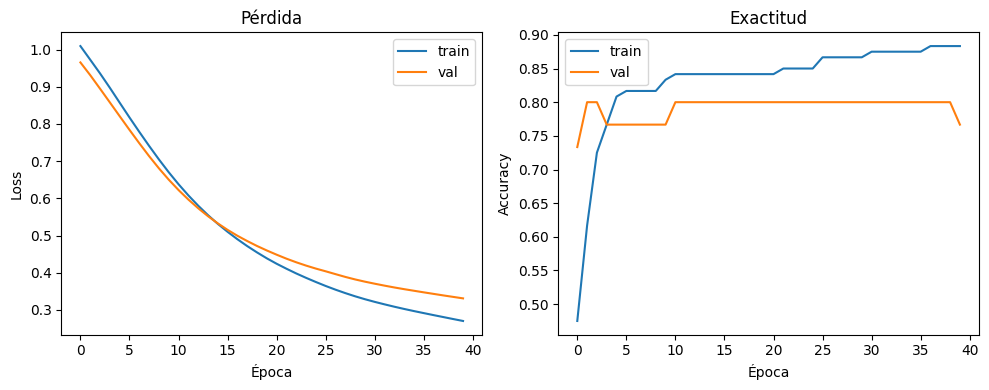

In [26]:
# 7. Graficar curvas de entrenamiento

def plot_history(history):
    plt.figure(figsize=(10, 4))

    # Pérdida
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Pérdida")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    # Exactitud
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Exactitud")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 8. Evaluar el modelo en el conjunto de validación

1. Evaluamos el modelo con `model.evaluate` sobre `X_val, y_val`.
2. Obtenemos la pérdida (`loss`) y la exactitud (`accuracy`) finales en validación.


In [27]:
# 8. Evaluar el modelo en validación
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Pérdida en validación: {loss:.4f}")
print(f"Exactitud en validación: {accuracy:.4f}")

Pérdida en validación: 0.3311
Exactitud en validación: 0.7667


## 9. Predicciones, métricas y matriz de confusión

1. Obtenemos probabilidades de cada clase con `model.predict`.
2. Convertimos las probabilidades a etiquetas predichas usando `argmax`.
3. Calculamos `classification_report`, `f1_score` promedio y la matriz de confusión.
4. Graficamos la matriz de confusión con etiquetas de clases.

Mini–ejemplo de interpretación de `softmax`:
- Si la salida es `[0.1, 0.7, 0.2]`, interpretamos 10 %, 70 % y 20 % de probabilidad para cada clase y elegimos la clase con probabilidad máxima (segunda clase).


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.80      0.40      0.53        10
   virginica       0.60      0.90      0.72        10

    accuracy                           0.77        30
   macro avg       0.80      0.77      0.75        30
weighted avg       0.80      0.77      0.75        30

F1 macro: 0.7511


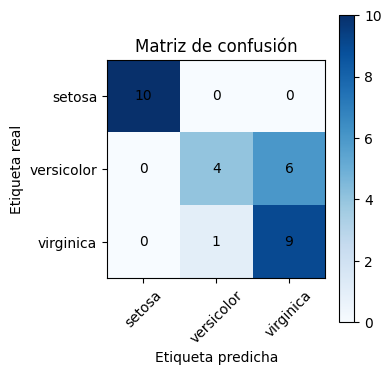

In [28]:
# 9. Predicciones y métricas

# 9.1 Obtener probabilidades y clases predichas
y_proba = model.predict(X_val)
y_pred = np.argmax(y_proba, axis=1)

# 9.2 Métricas de clasificación
print("Reporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))

macro_f1 = f1_score(y_val, y_pred, average="macro")
print(f"F1 macro: {macro_f1:.4f}")

# 9.3 Matriz de confusión
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(4, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks(range(3), data.target_names, rotation=45)
plt.yticks(range(3), data.target_names)
plt.xlabel("Etiqueta predicha")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

## 10. Guardar y cargar el modelo entrenado

1. Guardamos el modelo entrenado en disco para reutilizarlo sin reentrenar.
2. Cargamos el modelo desde el archivo y comprobamos que mantiene su rendimiento.

Interpretación: `model.save` almacena arquitectura, pesos y configuración; `load_model` permite volver a usar el modelo más adelante para nuevas predicciones.


In [29]:
# 10. Guardar y cargar el modelo entrenado

# 10.1 Guardar el modelo en disco
model.save("modelo_iris_rna.keras")
print("Modelo guardado en 'modelo_iris_rna.keras'")

# 10.2 Cargar el modelo desde disco
modelo_cargado = keras.models.load_model("modelo_iris_rna.keras")

# Verificar que el modelo cargado funciona
loss_loaded, acc_loaded = modelo_cargado.evaluate(X_val, y_val, verbose=0)
print(f"Exactitud del modelo cargado en validación: {acc_loaded:.4f}")

Modelo guardado en 'modelo_iris_rna.keras'
Exactitud del modelo cargado en validación: 0.7667


## 11. Predicción para un nuevo ejemplo

1. Definimos manualmente las características de una nueva flor.
2. Aplicamos el mismo escalado usado en el entrenamiento.
3. Obtenemos las probabilidades `softmax` para cada clase.
4. Convertimos esas probabilidades en una clase predicha y mostramos el nombre de la especie.

Mini–ejemplo: si la salida del `softmax` es `[0.95, 0.04, 0.01]`, interpretamos 95 %, 4 % y 1 % de probabilidad para cada clase y elegimos la clase con probabilidad máxima.


In [33]:
# 11. Predicción para un nuevo ejemplo

# 11.1 Definir una flor de ejemplo (valores típicos de setosa)
# [sepal_length, sepal_width, petal_length, petal_width]
nueva_flor = np.array([[5.7, 2.8, 4.1, 1.3]])

# 11.2 Aplicar el mismo escalado que al entrenamiento
nueva_flor_escalada = scaler.transform(nueva_flor)

# 11.3 Obtener probabilidades de clase
y_proba_nueva = model.predict(nueva_flor_escalada)
print("Probabilidades softmax:", y_proba_nueva)

# 11.4 Convertir a clase predicha y mostrar nombre
clase_predicha = np.argmax(y_proba_nueva, axis=1)[0]
nombre_clase = data.target_names[clase_predicha]

print(f"Clase predicha: {clase_predicha} -> {nombre_clase}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Probabilidades softmax: [[0.0724052 0.7561334 0.1714614]]
Clase predicha: 1 -> versicolor


## 12. Mejorar entrenamiento con EarlyStopping

1. Usamos `EarlyStopping` para detener el entrenamiento cuando la pérdida de validación deje de mejorar.
2. Esto ayuda a evitar sobreentrenamiento y suele dejar el modelo en el punto de mejor `val_loss`.
3. Volvemos a entrenar un nuevo modelo desde cero usando este callback.


In [31]:
# 12. Mejorar entrenamiento con EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

# 12.1 Crear un nuevo modelo desde cero
model_es = build_model(input_dim=X_train.shape[1], n_classes=3)

# 12.2 Definir callback de EarlyStopping
early_stop = EarlyStopping(
    monitor="val_loss",      # métrica a monitorear
    patience=5,               # número de épocas sin mejora antes de parar
    restore_best_weights=True # restaurar los mejores pesos obtenidos
)

# 12.3 Entrenar con EarlyStopping
history_es = model_es.fit(
    X_train,
    y_train,
    epochs=100,               # ponemos un máximo alto
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# 12.4 Evaluar modelo con EarlyStopping
loss_es, acc_es = model_es.evaluate(X_val, y_val, verbose=0)
print(f"Pérdida en validación (ES): {loss_es:.4f}")
print(f"Exactitud en validación (ES): {acc_es:.4f}")

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3333 - loss: 1.1909 - val_accuracy: 0.3333 - val_loss: 1.1502
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3417 - loss: 1.1374 - val_accuracy: 0.3333 - val_loss: 1.1041
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3333 - loss: 1.0897 - val_accuracy: 0.3000 - val_loss: 1.0615
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3500 - loss: 1.0473 - val_accuracy: 0.3000 - val_loss: 1.0248
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4083 - loss: 1.0137 - val_accuracy: 0.3667 - val_loss: 0.9957
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4667 - loss: 0.9875 - val_accuracy: 0.4000 - val_loss: 0.9731
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5750 - loss: 0.9653 - val_accuracy: 0.4333 - val_loss: 0.9532
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.9451 - val_accuracy: 0.6000 - val_loss:

## 13. Comparar la RNA con un modelo clásico (Regresión Logística)

1. Entrenamos una Regresión Logística sobre los mismos datos escalados.
2. Comparamos la exactitud y el F1 macro entre la RNA con EarlyStopping y la Regresión Logística.
3. Esto nos sirve como referencia para saber si la RNA está rindiendo tan bien como un modelo clásico fuerte en este dataset.


In [32]:
# 13. Comparar con Regresión Logística
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 13.1 Entrenar Regresión Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# 13.2 Evaluar en validación
y_pred_lr = log_reg.predict(X_val)
acc_lr = accuracy_score(y_val, y_pred_lr)
macro_f1_lr = f1_score(y_val, y_pred_lr, average="macro")

print(f"Accuracy Regresión Logística: {acc_lr:.4f}")
print(f"F1 macro Regresión Logística: {macro_f1_lr:.4f}")

# 13.3 Comparar con la RNA (EarlyStopping)
y_proba_es = model_es.predict(X_val)
y_pred_es = np.argmax(y_proba_es, axis=1)

macro_f1_es = f1_score(y_val, y_pred_es, average="macro")
print(f"F1 macro RNA (EarlyStopping): {macro_f1_es:.4f}")

Accuracy Regresión Logística: 0.9333
F1 macro Regresión Logística: 0.9333
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
F1 macro RNA (EarlyStopping): 0.9666


## 14. Resumen de mejoras aplicadas

1. Agregamos `EarlyStopping` para detener el entrenamiento cuando la validación deja de mejorar.
2. Comparamos el desempeño de la RNA contra Regresión Logística en el mismo conjunto de validación.
3. Con estos pasos puedes:
   - Ajustar arquitectura e hiperparámetros de la RNA.
   - Ver si tiene sentido usar una RNA o si un modelo clásico ya alcanza un rendimiento similar o mejor.
